<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN

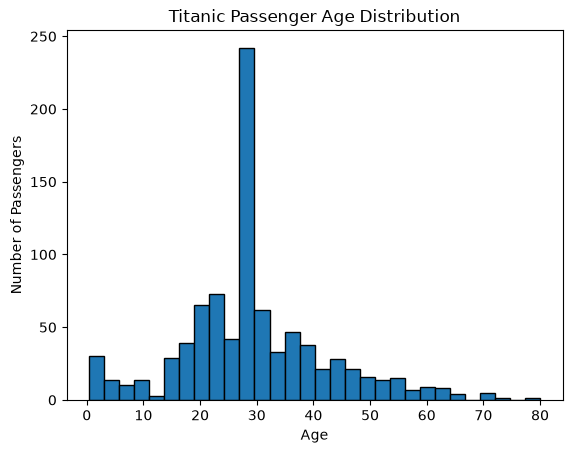

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.read_csv("Titanic-Dataset.csv")

print(df.info())
print(df.describe(include="all"))
print(df.isnull().sum())

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop(columns=["Cabin"])

label_encoder = LabelEncoder()
df["Sex"] = label_encoder.fit_transform(df["Sex"])

one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=int)
embarked_encoded = one_hot_encoder.fit_transform(df[["Embarked"]])
embarked_columns = one_hot_encoder.get_feature_names_out(["Embarked"])
embarked_encoded = pd.DataFrame(embarked_encoded, columns=embarked_columns, index=df.index)
df = pd.concat([df.drop(columns=["Embarked"]), embarked_encoded], axis=1)

plt.hist(df["Age"], bins=30, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passenger Age Distribution")
plt.show()

df.to_csv("Titanic-Cleaned-Dataset.csv", index=False)